In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import scipy
from PIL import Image
from scipy import ndimage
from utils import load_dataset

%matplotlib inline

In [ ]:
# Загрузка наборов данных
train_set_x_orig, train_set_y, test_set_x_orig, test_set_y, classes = load_dataset()

y = [1], это класс 'cat' изображений.


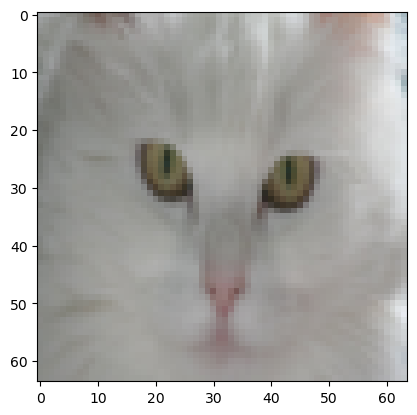

In [ ]:
# Пример изображения
index = 50
plt.imshow(train_set_x_orig[index])
print ("y = " + str(train_set_y[:, index]) + ", это класс '" + classes[np.squeeze(train_set_y[:, index])].decode("utf-8") + "' изображений.")

y = [0], это класс 'non-cat' изображений.


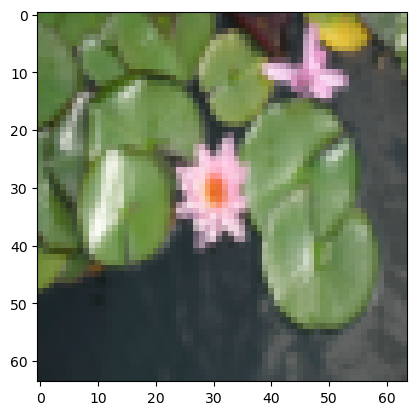

In [ ]:
index = 26
plt.imshow(train_set_x_orig[index])
print ("y = " + str(train_set_y[:, index]) + ", это класс '" + classes[np.squeeze(train_set_y[:, index])].decode("utf-8") + "' изображений.")

In [ ]:
m_train = train_set_x_orig.shape[0]
m_test = test_set_x_orig.shape[0]
num_px = train_set_x_orig.shape[2]
num_py = train_set_x_orig.shape[1]

print ("Количество обучающих примеров: m_train = " + str(m_train))
print ("Количество тестовых примеров: m_test = " + str(m_test))
print ("Ширина изображения: num_px = " + str(num_px))
print ("Высота изображения: num_py = " + str(num_py))
print ("Форма массива изображения: (" + str(num_py) + ", " + str(num_px) + ", 3)")
print ("train_set_x shape: " + str(train_set_x_orig.shape))
print ("train_set_y shape: " + str(train_set_y.shape))
print ("test_set_x shape: " + str(test_set_x_orig.shape))
print ("test_set_y shape: " + str(test_set_y.shape))

Количество обучающих примеров: m_train = 209
Количество тестовых примеров: m_test = 50
Ширина изображения: num_px = 64
Высота изображения: num_py = 64
Форма массива изображения: (64, 64, 3)
train_set_x shape: (209, 64, 64, 3)
train_set_y shape: (1, 209)
test_set_x shape: (50, 64, 64, 3)
test_set_y shape: (1, 50)


In [ ]:
train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T

print ("train_set_x_flatten shape: " + str(train_set_x_flatten.shape))
print ("train_set_y shape: " + str(train_set_y.shape))
print ("test_set_x_flatten shape: " + str(test_set_x_flatten.shape))
print ("test_set_y shape: " + str(test_set_y.shape))

train_set_x_flatten shape: (12288, 209)
train_set_y shape: (1, 209)
test_set_x_flatten shape: (12288, 50)
test_set_y shape: (1, 50)


In [ ]:
# Проверка правильности измнения формы массивов
assert np.array_equal(train_set_x_flatten[0:5,0],np.array([17, 31, 56, 22, 33]))

In [ ]:
train_set_x = train_set_x_flatten/255.
test_set_x = test_set_x_flatten/255.

In [ ]:
# Функция активации: sigmoid

def sigmoid(z):
    s = 1 / (1 + np.exp(-z))
    return s

In [ ]:
assert sigmoid(np.array([0,2]))[0] == 0.5
assert round(sigmoid(np.array([0,2]))[1], 6) == 0.880797

In [ ]:
# Инициализация нулями: initialize_with_zeros

def initialize_with_zeros(dim):

    w = np.zeros((dim,1))
    b = 0

    assert(w.shape == (dim, 1))
    assert(isinstance(b, float) or isinstance(b, int))

    return w, b

In [ ]:
dim = 2
w, b = initialize_with_zeros(dim)
assert np.array_equal(w,np.array([[0.],[0.]]))
assert np.array_equal(b,0)

In [ ]:
def propagate(w, b, X, Y):
    m = X.shape[1]
    A = sigmoid(np.dot(w.T, X) + b)
    cost = -1/m * np.sum(Y * np.log(A) + (1-Y) * np.log(1-A))
    return cost

In [ ]:
w, b, X, Y = np.array([[1],[2]]), 2, np.array([[1,2],[3,4]]), np.array([[1,0]])
cost = propagate(w, b, X, Y)

assert np.round(cost) == 6

In [ ]:
# Прямое и обратное распространение ошибки: grad_propagate

def grad_propagate(w, b, X, Y):
    m = X.shape[1]
    A = 1 / (1 + np.exp(-(np.dot(w.T, X) + b)))
    cost = - 1 / m * np.sum(Y * np.log(A) + (1 - Y) * np.log(1 - A))
    dw = 1 / m * np.dot(X, (A - Y).T)
    db = 1 / m * np.sum(A - Y)

    assert(dw.shape == w.shape)
    assert(db.dtype == float)
    cost = np.squeeze(cost)
    assert(cost.shape == ())

    grads = {"dw": dw,
             "db": db}

    return grads, cost

In [ ]:
w, b, X, Y = np.array([[1],[2]]), 2, np.array([[1,2],[3,4]]), np.array([[1,0]])
grads, cost = grad_propagate(w, b, X, Y)

assert np.round(grads["dw"])[0] == 1
assert np.round(grads["dw"])[1] == 2
assert np.round(grads["db"],1) == 0.5
assert np.round(cost) == 6

In [ ]:
# Функция оптимизации: optimize

def optimize(w, b, X, Y, num_iterations, learning_rate, print_cost = False):
    costs = []
    for i in range(num_iterations):

        # Вычисление градиента и функции стоимости
        m = X.shape[1]
        A = 1 / (1 + np.exp(-(np.dot(w.T, X) + b)))
        cost = - 1 / m * np.sum(Y * np.log(A) + (1 - Y) * np.log(1 - A))
        dw = 1 / m * np.dot(X, (A - Y).T)
        db = 1 / m * np.sum(A - Y)

        # обновление весов
        w = w - learning_rate * dw
        b = b - learning_rate * db

        if i % 100 == 0:
            costs.append(cost)

        if print_cost and i % 100 == 0:
            print ("Cost after iteration %i: %f" %(i, cost))

    params = {"w": w,
              "b": b}
    grads = {"dw": dw,
             "db": db}
    return params, grads, costs

In [ ]:
params, grads, costs = optimize(w, b, X, Y, num_iterations= 100, learning_rate = 0.009, print_cost = False)

pw = params["w"]
pb = params["b"]
assert np.round(pw,5)[0] == 0.11246
assert np.round(pw,5)[1] == 0.23107
assert np.round(pb,5) == 1.55930

assert np.round(grads["dw"],5)[0] == 0.90158
assert np.round(grads["dw"],5)[1] == 1.76251
assert np.round(grads["db"],5) == 0.43046

In [ ]:
# Функция классификации: predict

def predict(w, b, X):
    m = X.shape[1]
    Y_prediction = np.zeros((1,m))
    w = w.reshape(X.shape[0], 1)

    A = 1 / (1 + np.exp(-(np.dot(w.T, X) + b)))

    Y_prediction = np.where(A <= 0.5, 0, 1)

    assert(Y_prediction.shape == (1, m))

    return Y_prediction

In [ ]:
assert np.array_equal(predict(w, b, X),np.array([[1.,1.]]))

In [ ]:
# Модель классификатора: model

def model(X_train, Y_train, X_test, Y_test, num_iterations = 2000, learning_rate = 0.005, print_cost = False):

    # инициализация параметов (w, b)
    dim = 64*64*3
    w, b = initialize_with_zeros(dim)

    # Градиентный спуск
    params, grads, costs = optimize(w, b, X_train, Y_train, num_iterations, learning_rate, print_cost=False)

    w = params["w"]
    b = params["b"]

    # Предсказание Y_prediction_test, Y_prediction_train
    Y_prediction_train = predict(w, b, X_train)
    Y_prediction_test = predict(w, b, X_test)

    print("train accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100))
    print("test accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100))


    d = {"costs": costs,
         "Y_prediction_test": Y_prediction_test,
         "Y_prediction_train" : Y_prediction_train,
         "w" : w,
         "b" : b,
         "learning_rate" : learning_rate,
         "num_iterations": num_iterations}

    return d

In [ ]:
# Обучим полученную модель
d = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations = 2000, learning_rate = 0.005, print_cost = True)

train accuracy: 99.04306220095694 %
test accuracy: 70.0 %


In [ ]:
index = 6
plt.imshow(test_set_x[:,index].reshape((64, 64 , 3)))
print ("y = " + str(test_set_y[0,index]) + ", предсказание нейросети: \"" + classes[int(d["Y_prediction_test"][0,index])].decode("utf-8") +  "\" на изображении.")

Построим график обучения сети: график зависимости функции стоимости от времени обучения

In [ ]:
costs = np.squeeze(d['costs'])
l_r = np.squeeze(d['learning_rate'])
print(l_r)
plt.plot(costs)
plt.ylabel('ошибка')
plt.xlabel('число итераций обучения')
plt.title("Скорость обучения =" + str(d["learning_rate"]))
plt.show()

In [ ]:
learning_rates = [0.01, 0.0015, 0.001]
models = {}
for i in learning_rates:
    print ("learning rate is: " + str(i))
    models[str(i)] = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations = 5000, learning_rate = i, print_cost = False)
    print ('\n' + "-------------------------------------------------------" + '\n')

for i in learning_rates:
    plt.plot(np.squeeze(models[str(i)]["costs"]), label= str(models[str(i)]["learning_rate"]))

plt.ylabel('ошибка')
plt.xlabel('число итераций обучения')

legend = plt.legend(loc='upper center', shadow=True)
frame = legend.get_frame()
frame.set_facecolor('0.90')
plt.show()

In [ ]:
from skimage import transform
from skimage.io import imread

num_py = 64
num_px = 64

"""my_image = Укажите имя вашего изображения в папке images"""
my_image = "my_image_cat.jpg"

# Загрузка указанного изображения
fname = "images/" + my_image
image = np.array(imread(fname))

# Предобработка и изменение размера изображения
image = image/255.
image = transform.resize(image, [num_py,num_px,3])
my_image = image.reshape((1, num_py*num_px*3)).T

my_predicted_image = predict(d["w"], d["b"], my_image)

plt.imshow(image)
print("y = " + str(np.squeeze(my_predicted_image)) + ", предсказание нейросети: \"" + classes[int(np.squeeze(my_predicted_image)),].decode("utf-8") +  "\" на изображении.")